In [1]:
#CUSTOMER CHURN PREDICTION USING MACHINE LEARNING

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix, roc_auc_score)

In [6]:
#Load the dataset 
df = pd.read_csv("Telco-Customer-Churn(3).csv") 
print(df.head())
print(df.shape)
print(df.info)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [8]:
# Data Understanding & EDA 
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [9]:
#Missing Values
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [13]:
#Duplicate rows
df.duplicated().sum()

0

In [15]:
#CONVERT TARGET VARIABLES 
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [35]:
#DEFINE FEATURES AND TARGET
X = df.drop('Churn', axis=1)
y = df['Churn']

In [42]:
#SPLIT DATASET
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
#TRAIN-TEST
model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


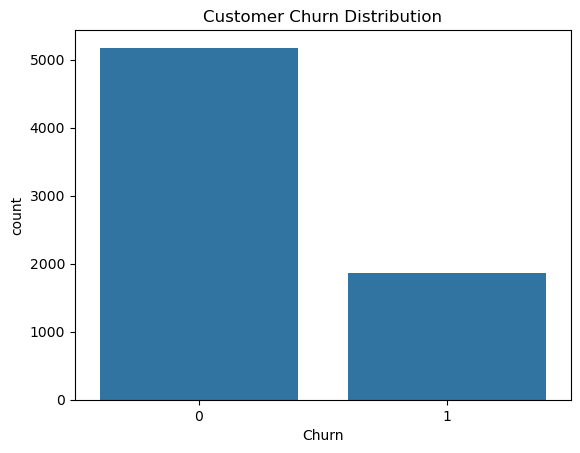

In [51]:
# EXPLORATORY DATA ANALYSIS (EDA)
# CHURN DISTRIBUTION
sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()

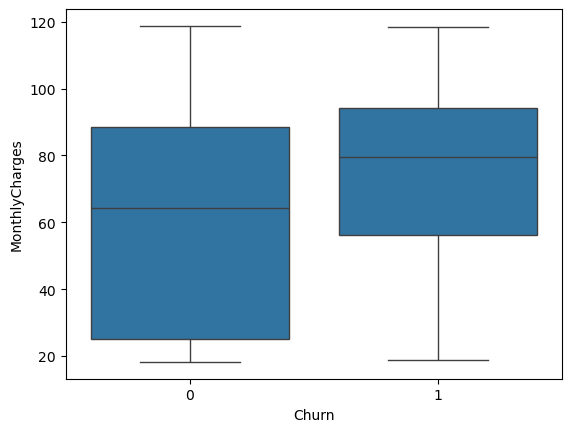

In [52]:
#MONTHLY CHARGES VS CHURN
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.show()

In [53]:
#DATA ENCODING
#Convert categorical variables into numerical values
le=LabelEncoder()

df["Churn"]=le.fit_transform(
    df["Churn"]
)

df=pd.get_dummies(
    df,
    drop_first=True
)

In [54]:
#FEATURE ENGINEERING
#Customer spending category
df["SpendingLevel"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0,35,70,120],
    labels=["Low","Medium","High"]
)

df=pd.get_dummies(
    df,
    columns=["SpendingLevel"],
    drop_first=True
)

In [55]:
#FEATURE AND TARGET SELECTION
X=df.drop(
    "Churn",
    axis=1
)

y=df["Churn"]

In [56]:
#PREDICTION
y_pred=model.predict(
    X_test
)

print(y_pred[:10])

[1 0 0 1 0 0 0 0 0 0]


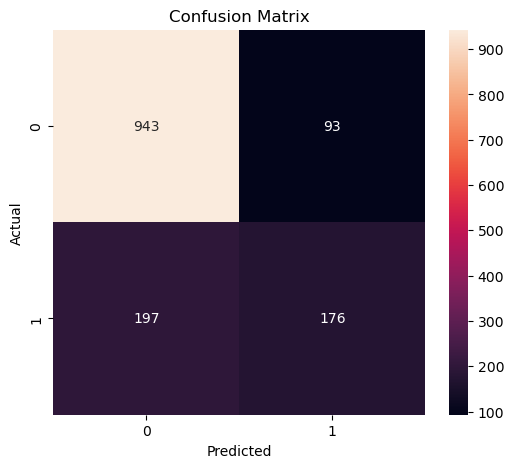

In [57]:
#VISUALIZATION
#Confusion Matrix Visualization
cm=confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)

plt.show()

In [58]:
#MODEL EVALUATION
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred
    )
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_pred
    )
)

Accuracy: 0.794180269694819
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.47      0.55       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.6910407630917014
